# SmartCare Guardian — Health Risk Prediction Model Training

IMPORT LIBRARIES

In [5]:
import sys
!"{sys.executable}" -m pip install xgboost


Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")

All libraries imported!


LOAD DATA

In [43]:
train_data = pd.read_csv('data/health_logs_train.csv')
test_data  = pd.read_csv('data/health_logs_test.csv')

print(f"Train shape: {train_data.shape}")
print(f"Test shape:  {test_data.shape}")
print(f"\nColumns: {train_data.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(train_data.head(3))

Train shape: (7200, 10)
Test shape:  (1800, 10)

Columns: ['resident_id', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'blood_sugar', 'pulse', 'weight', 'temperature', 'oxygen_saturation', 'risk_label', 'logged_at']

First 3 rows:
   resident_id  blood_pressure_systolic  blood_pressure_diastolic  \
0            1                      121                        71   
1            1                      123                        70   
2            1                      107                        70   

   blood_sugar  pulse  weight  temperature  oxygen_saturation  risk_label  \
0        100.7     91    74.4         36.4               95.7           0   
1         99.6     81    73.4         36.4               96.3           0   
2         83.5     85    74.4         36.3               94.2           0   

             logged_at  
0  2024-01-01 07:57:00  
1  2024-01-02 07:49:00  
2  2024-01-03 10:03:00  


PREPARE FEATURES

In [44]:
target_column = 'risk_label'
drop_columns  = ['resident_id', 'logged_at', target_column]

X_train = train_data.drop(columns=drop_columns)
y_train = train_data[target_column]

X_test  = test_data.drop(columns=drop_columns)
y_test  = test_data[target_column]

print(f"\nFeatures used for training:")
for col in X_train.columns:
    print(f"  - {col}")

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\nTarget distribution (train):")
print(y_train.value_counts())
print(f"Risk percentage (train): {y_train.mean()*100:.1f}%")
print(f"\nTarget distribution (test):")
print(y_test.value_counts())
print(f"Risk percentage (test): {y_test.mean()*100:.1f}%")


Features used for training:
  - blood_pressure_systolic
  - blood_pressure_diastolic
  - blood_sugar
  - pulse
  - weight
  - temperature
  - oxygen_saturation

X_train shape: (7200, 7)
X_test shape:  (1800, 7)

Target distribution (train):
risk_label
0    5700
1    1500
Name: count, dtype: int64
Risk percentage (train): 20.8%

Target distribution (test):
risk_label
0    1405
1     395
Name: count, dtype: int64
Risk percentage (test): 21.9%


ADD TIME-BASED FEATURES

In [45]:
def add_time_features(df):
    df = df.copy()
    df['logged_at'] = pd.to_datetime(df['logged_at'])
    df['hour']        = df['logged_at'].dt.hour
    df['day_of_week'] = df['logged_at'].dt.dayofweek   # 0=Mon, 6=Sun
    df['month']       = df['logged_at'].dt.month
    return df

train_data_fe = add_time_features(train_data)
test_data_fe  = add_time_features(test_data)

feature_cols = [
    'blood_pressure_systolic', 'blood_pressure_diastolic',
    'blood_sugar', 'pulse', 'weight',
    'temperature', 'oxygen_saturation',
    'hour', 'day_of_week', 'month'
]

X_train = train_data_fe[feature_cols]
y_train = train_data_fe[target_column]

X_test  = test_data_fe[feature_cols]
y_test  = test_data_fe[target_column]

print(f"\nFeatures after adding time features: {X_train.shape[1]}")
print(f"Feature list: {feature_cols}")


Features after adding time features: 10
Feature list: ['blood_pressure_systolic', 'blood_pressure_diastolic', 'blood_sugar', 'pulse', 'weight', 'temperature', 'oxygen_saturation', 'hour', 'day_of_week', 'month']


CHECK MISSING VALUES

In [46]:
print(f"\nMissing values in train: {X_train.isnull().sum().sum()}")
print(f"Missing values in test:  {X_test.isnull().sum().sum()}")

if X_train.isnull().sum().sum() > 0:
    X_train = X_train.fillna(X_train.median())
    X_test  = X_test.fillna(X_test.median())
    print("Missing values filled with median")


Missing values in train: 0
Missing values in test:  0


PREPROCESSING FOR RANDOM FOREST & XGBOOST

In [47]:
tree_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
    # No StandardScaler — not needed for tree-based models
])

X_train_tree = tree_preprocessor.fit_transform(X_train)
X_test_tree  = tree_preprocessor.transform(X_test)

print(f"\nTree preprocessor applied.")
print(f"X_train_tree shape: {X_train_tree.shape}")


Tree preprocessor applied.
X_train_tree shape: (7200, 10)


TRAIN RANDOM FOREST

In [48]:
print("\n" + "=" * 60)
print("RANDOM FOREST — TRAINING")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    class_weight='balanced'
)

rf_model.fit(X_train_tree, y_train)
print("\nRandom Forest training complete!")


RANDOM FOREST — TRAINING


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.3s



Random Forest training complete!


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.6s finished


EVALUATE RANDOM FOREST


RANDOM FOREST — EVALUATION ON TEST DATA

Accuracy:  0.8461
Precision: 0.8882
Recall:    0.3418
F1-Score:  0.4936
AUC-ROC:   0.8768

Classification Report:
              precision    recall  f1-score   support

      Normal       0.84      0.99      0.91      1405
     At Risk       0.89      0.34      0.49       395

    accuracy                           0.85      1800
   macro avg       0.87      0.66      0.70      1800
weighted avg       0.85      0.85      0.82      1800



[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.0s finished


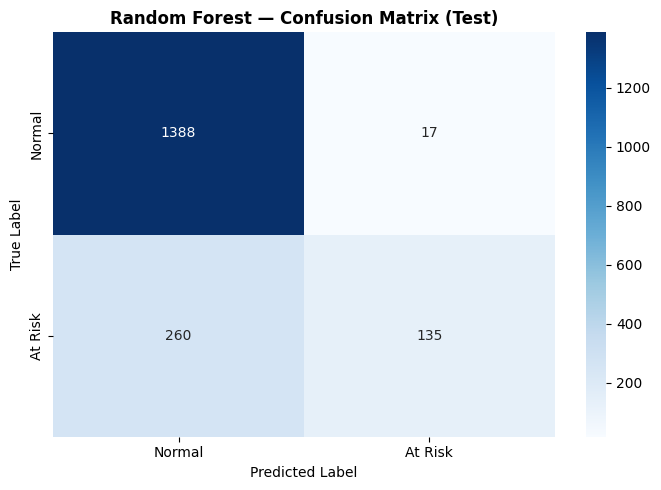


True Negatives  (Normal correctly identified):  1388
False Positives (Normal wrongly flagged as risk): 17
False Negatives (Risk missed):                    260
True Positives  (Risk correctly detected):        135


In [49]:
print("\n" + "=" * 60)
print("RANDOM FOREST — EVALUATION ON TEST DATA")
print("=" * 60)

y_pred_rf       = rf_model.predict(X_test_tree)
y_pred_proba_rf = rf_model.predict_proba(X_test_tree)[:, 1]

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_pred_proba_rf)

print(f"\nAccuracy:  {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall:    {rec_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")
print(f"AUC-ROC:   {auc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
                            target_names=['Normal', 'At Risk']))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'At Risk'],
            yticklabels=['Normal', 'At Risk'])
plt.title('Random Forest — Confusion Matrix (Test)', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('visualizations/rf_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTrue Negatives  (Normal correctly identified):  {cm_rf[0,0]}")
print(f"False Positives (Normal wrongly flagged as risk): {cm_rf[0,1]}")
print(f"False Negatives (Risk missed):                    {cm_rf[1,0]}")
print(f"True Positives  (Risk correctly detected):        {cm_rf[1,1]}")

RANDOM FOREST FEATURE IMPORTANCE


RANDOM FOREST — FEATURE IMPORTANCE

Feature Importances:
                 feature  importance
       oxygen_saturation    0.258699
 blood_pressure_systolic    0.223156
             blood_sugar    0.115817
blood_pressure_diastolic    0.109852
                   pulse    0.085876
                  weight    0.078544
             temperature    0.045848
             day_of_week    0.032167
                   month    0.028546
                    hour    0.021495


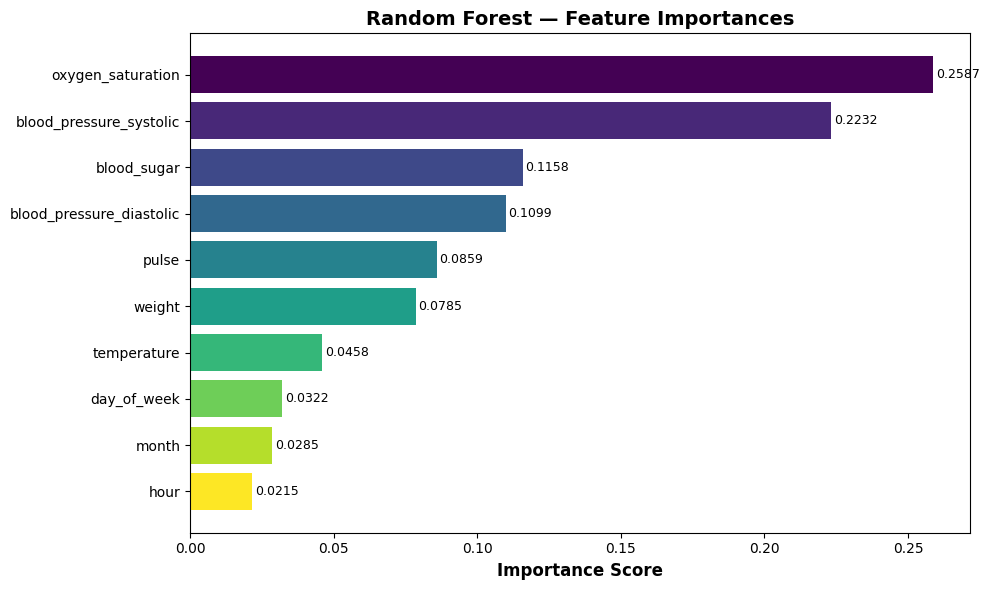

In [50]:
print("\n" + "=" * 60)
print("RANDOM FOREST — FEATURE IMPORTANCE")
print("=" * 60)

rf_feat_imp = pd.DataFrame({
    'feature':    feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importances:")
print(rf_feat_imp.to_string(index=False))

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(rf_feat_imp)))
plt.barh(range(len(rf_feat_imp)), rf_feat_imp['importance'], color=colors)
plt.yticks(range(len(rf_feat_imp)), rf_feat_imp['feature'])
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.title('Random Forest — Feature Importances', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for i, v in enumerate(rf_feat_imp['importance']):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('visualizations/rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

SAVE RANDOM FOREST

In [51]:
joblib.dump(rf_model,         'models/rf_model.pkl')
joblib.dump(tree_preprocessor, 'models/tree_preprocessor.pkl')
print("Random Forest saved: models/rf_model.pkl")

Random Forest saved: models/rf_model.pkl


TRAIN XGBOOST BASELINE

In [52]:
# Calculate class imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos  # Example: 6900/300 = 23

print(f"Class imbalance ratio: {scale_pos_weight:.2f}")
print(f"  Normal samples: {neg}")
print(f"  Risk samples:   {pos}")

Class imbalance ratio: 3.80
  Normal samples: 5700
  Risk samples:   1500


In [53]:
print("\n" + "=" * 60)
print("XGBOOST — BASELINE TRAINING")
print("=" * 60)

xgb_baseline = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='auc',
    verbosity=1,
    scale_pos_weight=scale_pos_weight
)

xgb_baseline.fit(X_train_tree, y_train)
print("\nXGBoost baseline training complete!")


XGBOOST — BASELINE TRAINING

XGBoost baseline training complete!


EVALUATE XGBOOST BASELINE

In [54]:
print("\n" + "=" * 60)
print("XGBOOST — BASELINE EVALUATION ON TEST DATA")
print("=" * 60)

y_pred_xgb_base       = xgb_baseline.predict(X_test_tree)
y_pred_proba_xgb_base = xgb_baseline.predict_proba(X_test_tree)[:, 1]

acc_xgb_base  = accuracy_score(y_test, y_pred_xgb_base)
auc_xgb_base  = roc_auc_score(y_test, y_pred_proba_xgb_base)

print(f"Baseline Accuracy: {acc_xgb_base:.4f}")
print(f"Baseline AUC-ROC:  {auc_xgb_base:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_base,
                            target_names=['Normal', 'At Risk']))


XGBOOST — BASELINE EVALUATION ON TEST DATA
Baseline Accuracy: 0.8128
Baseline AUC-ROC:  0.8715

Classification Report:
              precision    recall  f1-score   support

      Normal       0.88      0.88      0.88      1405
     At Risk       0.57      0.59      0.58       395

    accuracy                           0.81      1800
   macro avg       0.73      0.73      0.73      1800
weighted avg       0.81      0.81      0.81      1800



XGBOOST HYPERPARAMETER TUNING

In [55]:
print("\n" + "=" * 60)
print("XGBOOST — HYPERPARAMETER TUNING")
print("=" * 60)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"Class balance ratio (scale_pos_weight): {scale_pos_weight:.4f}")

param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.05, 0.1],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [scale_pos_weight]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='auc',
        verbosity=0
    ),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_tree, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV AUC:      {grid_search.best_score_:.4f}")


XGBOOST — HYPERPARAMETER TUNING
Class balance ratio (scale_pos_weight): 3.8000
Fitting 3 folds for each of 48 candidates, totalling 144 fits

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': np.float64(3.8), 'subsample': 0.8}
Best CV AUC:      0.8041


EVALUATE XGBOOST OPTIMIZED


XGBOOST — OPTIMIZED EVALUATION ON TEST DATA

Accuracy:  0.7556
Precision: 0.4670
Recall:    0.8051
F1-Score:  0.5911
AUC-ROC:   0.8892

Improvement over Baseline:
  Accuracy: -0.0572
  AUC-ROC:  +0.0177

Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.74      0.83      1405
     At Risk       0.47      0.81      0.59       395

    accuracy                           0.76      1800
   macro avg       0.70      0.77      0.71      1800
weighted avg       0.83      0.76      0.77      1800



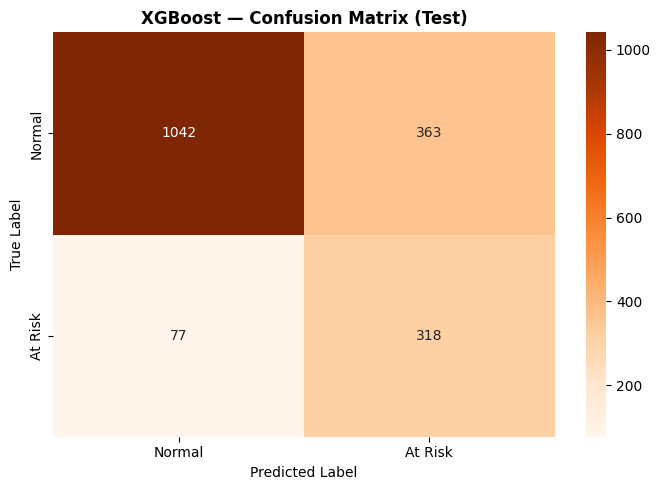


True Negatives  (Normal correctly identified):   1042
False Positives (Normal wrongly flagged as risk): 363
False Negatives (Risk missed):                    77
True Positives  (Risk correctly detected):        318


In [56]:
print("\n" + "=" * 60)
print("XGBOOST — OPTIMIZED EVALUATION ON TEST DATA")
print("=" * 60)

xgb_optimized = grid_search.best_estimator_

y_pred_xgb_opt       = xgb_optimized.predict(X_test_tree)
y_pred_proba_xgb_opt = xgb_optimized.predict_proba(X_test_tree)[:, 1]

acc_xgb_opt  = accuracy_score(y_test, y_pred_xgb_opt)
prec_xgb_opt = precision_score(y_test, y_pred_xgb_opt)
rec_xgb_opt  = recall_score(y_test, y_pred_xgb_opt)
f1_xgb_opt   = f1_score(y_test, y_pred_xgb_opt)
auc_xgb_opt  = roc_auc_score(y_test, y_pred_proba_xgb_opt)

print(f"\nAccuracy:  {acc_xgb_opt:.4f}")
print(f"Precision: {prec_xgb_opt:.4f}")
print(f"Recall:    {rec_xgb_opt:.4f}")
print(f"F1-Score:  {f1_xgb_opt:.4f}")
print(f"AUC-ROC:   {auc_xgb_opt:.4f}")

print(f"\nImprovement over Baseline:")
print(f"  Accuracy: {acc_xgb_opt - acc_xgb_base:+.4f}")
print(f"  AUC-ROC:  {auc_xgb_opt - auc_xgb_base:+.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_opt,
                            target_names=['Normal', 'At Risk']))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb_opt)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'At Risk'],
            yticklabels=['Normal', 'At Risk'])
plt.title('XGBoost — Confusion Matrix (Test)', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('visualizations/xgb_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTrue Negatives  (Normal correctly identified):   {cm_xgb[0,0]}")
print(f"False Positives (Normal wrongly flagged as risk): {cm_xgb[0,1]}")
print(f"False Negatives (Risk missed):                    {cm_xgb[1,0]}")
print(f"True Positives  (Risk correctly detected):        {cm_xgb[1,1]}")

XGBOOST FEATURE IMPORTANCE


XGBOOST — FEATURE IMPORTANCE

Feature Importances:
                 feature  importance
       oxygen_saturation    0.295844
 blood_pressure_systolic    0.286859
blood_pressure_diastolic    0.194081
                   pulse    0.073936
             blood_sugar    0.073631
                  weight    0.035804
             temperature    0.015715
                   month    0.009845
             day_of_week    0.007760
                    hour    0.006526


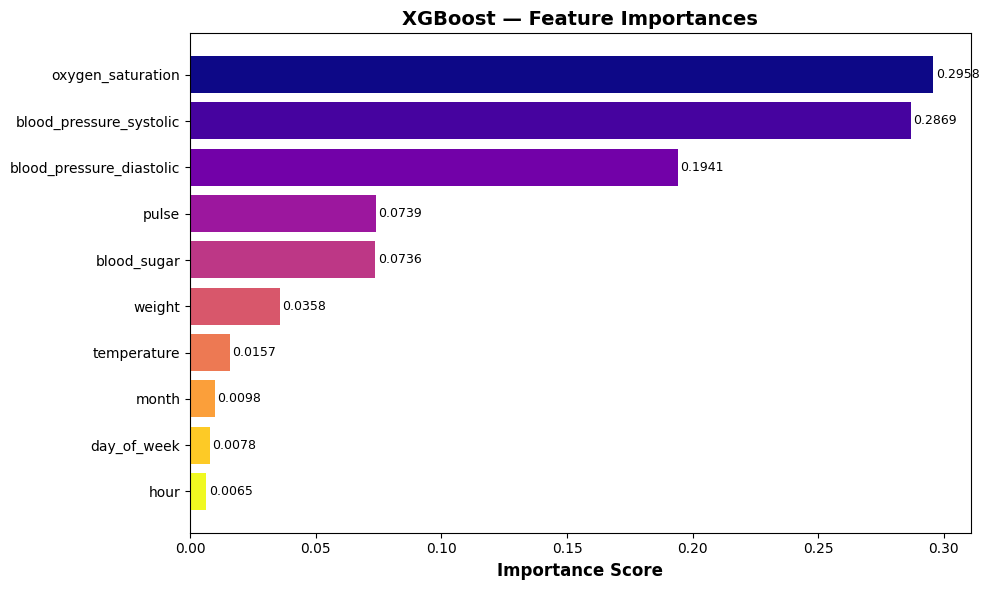

In [57]:
print("\n" + "=" * 60)
print("XGBOOST — FEATURE IMPORTANCE")
print("=" * 60)

xgb_feat_imp = pd.DataFrame({
    'feature':    feature_cols,
    'importance': xgb_optimized.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importances:")
print(xgb_feat_imp.to_string(index=False))

plt.figure(figsize=(10, 6))
colors = plt.cm.plasma(np.linspace(0, 1, len(xgb_feat_imp)))
plt.barh(range(len(xgb_feat_imp)), xgb_feat_imp['importance'], color=colors)
plt.yticks(range(len(xgb_feat_imp)), xgb_feat_imp['feature'])
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.title('XGBoost — Feature Importances', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for i, v in enumerate(xgb_feat_imp['importance']):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('visualizations/xgb_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

SAVE XGBOOST

In [58]:
joblib.dump(xgb_optimized, 'models/xgb_model.pkl')
print("XGBoost saved: models/xgb_model.pkl")

XGBoost saved: models/xgb_model.pkl


PREPROCESSING FOR ANN

In [59]:
print("\n" + "=" * 60)
print("ANN — PREPROCESSING (With Scaling)")
print("=" * 60)

ann_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())   # REQUIRED for ANN
])

X_train_ann = ann_preprocessor.fit_transform(X_train)
X_test_ann  = ann_preprocessor.transform(X_test)

print(f"X_train_ann shape: {X_train_ann.shape}")
print(f"X_test_ann shape:  {X_test_ann.shape}")
print("Preprocessing done: Imputation + StandardScaling applied")


ANN — PREPROCESSING (With Scaling)
X_train_ann shape: (7200, 10)
X_test_ann shape:  (1800, 10)
Preprocessing done: Imputation + StandardScaling applied


Handling Class Imbalance

In [60]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print(f"Class weights for ANN: {class_weight_dict}")

Class weights for ANN: {0: np.float64(0.631578947368421), 1: np.float64(2.4)}


BUILD AND COMPILE ANN

In [61]:
print("\n" + "=" * 60)
print("ANN — BUILD & COMPILE")
print("=" * 60)

def create_ann(input_dim):
    model = keras.Sequential([
        # Input layer
        layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.3),

        # Hidden layers
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(16, activation='relu'),
        layers.Dropout(0.2),

        # Output — sigmoid for binary classification (0 or 1)
        layers.Dense(1, activation='sigmoid')
    ])
    return model

ann_model = create_ann(X_train_ann.shape[1])
ann_model.summary()

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
print("\nANN compiled!")


ANN — BUILD & COMPILE


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)


ANN compiled!


TRAIN ANN

In [62]:
print("\n" + "=" * 60)
print("ANN — TRAINING")
print("=" * 60)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'models/best_ann_model.keras',
    monitor='val_auc',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Use test set as validation so we can monitor real performance
history = ann_model.fit(
    X_train_ann, y_train,
    validation_data=(X_test_ann, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, checkpoint],
    class_weight=class_weight_dict,  
    verbose=1
)

print("\nANN training complete!")


ANN — TRAINING
Epoch 1/100
222/225 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5885 - auc: 0.7313 - loss: 0.6078
Epoch 1: val_auc improved from None to 0.82154, saving model to models/best_ann_model.keras

Epoch 1: finished saving model to models/best_ann_model.keras
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6967 - auc: 0.8106 - loss: 0.5431 - val_accuracy: 0.7567 - val_auc: 0.8215 - val_loss: 0.4680
Epoch 2/100
217/225 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7609 - auc: 0.8640 - loss: 0.4449
Epoch 2: val_auc improved from 0.82154 to 0.83752, saving model to models/best_ann_model.keras

Epoch 2: finished saving model to models/best_ann_model.keras
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7589 - auc: 0.8634 - loss: 0.4443 - val_accuracy: 0.7417 - val_auc: 0.8375 - val_loss: 0.4550
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7580 - auc: 0.8739 - loss: 0.4206
Epoch 3: val_auc improved from 0.83752 to 0.84314, saving model to mod

PLOT ANN TRAINING HISTORY

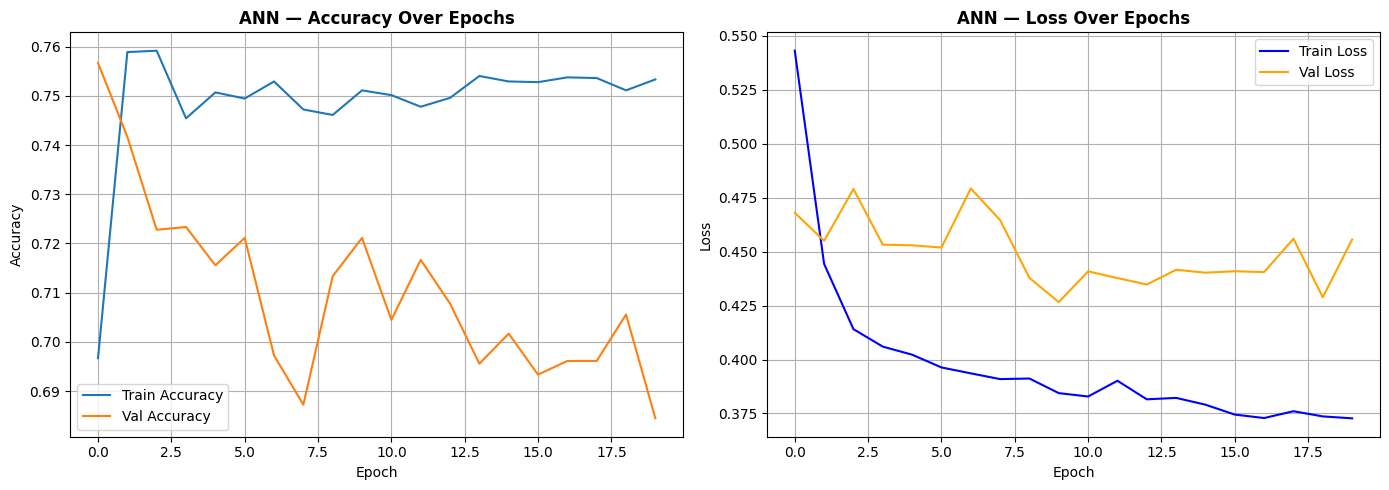

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('ANN — Accuracy Over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train Loss',     color='blue')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[1].set_title('ANN — Loss Over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('visualizations/ann_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

EVALUATE ANN


ANN — EVALUATION ON TEST DATA
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Accuracy:  0.7211
Precision: 0.4322
Recall:    0.8633
F1-Score:  0.5760
AUC-ROC:   0.8538

Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.68      0.79      1405
     At Risk       0.43      0.86      0.58       395

    accuracy                           0.72      1800
   macro avg       0.69      0.77      0.68      1800
weighted avg       0.83      0.72      0.74      1800



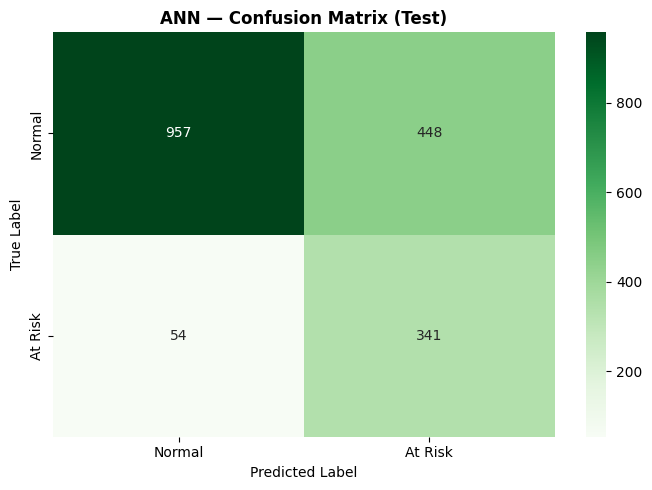


True Negatives  (Normal correctly identified):   957
False Positives (Normal wrongly flagged as risk): 448
False Negatives (Risk missed):                    54
True Positives  (Risk correctly detected):        341


In [64]:
print("\n" + "=" * 60)
print("ANN — EVALUATION ON TEST DATA")
print("=" * 60)

y_pred_proba_ann = ann_model.predict(X_test_ann)
y_pred_ann       = (y_pred_proba_ann > 0.5).astype(int).flatten()

acc_ann  = accuracy_score(y_test, y_pred_ann)
prec_ann = precision_score(y_test, y_pred_ann)
rec_ann  = recall_score(y_test, y_pred_ann)
f1_ann   = f1_score(y_test, y_pred_ann)
auc_ann  = roc_auc_score(y_test, y_pred_proba_ann)

print(f"\nAccuracy:  {acc_ann:.4f}")
print(f"Precision: {prec_ann:.4f}")
print(f"Recall:    {rec_ann:.4f}")
print(f"F1-Score:  {f1_ann:.4f}")
print(f"AUC-ROC:   {auc_ann:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann,
                            target_names=['Normal', 'At Risk']))

# Confusion Matrix
cm_ann = confusion_matrix(y_test, y_pred_ann)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'At Risk'],
            yticklabels=['Normal', 'At Risk'])
plt.title('ANN — Confusion Matrix (Test)', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('visualizations/ann_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTrue Negatives  (Normal correctly identified):   {cm_ann[0,0]}")
print(f"False Positives (Normal wrongly flagged as risk): {cm_ann[0,1]}")
print(f"False Negatives (Risk missed):                    {cm_ann[1,0]}")
print(f"True Positives  (Risk correctly detected):        {cm_ann[1,1]}")

SAVE ANN

In [65]:
ann_model.save('models/ann_model.keras')
joblib.dump(ann_preprocessor, 'models/ann_preprocessor.pkl')
print("ANN saved:          models/ann_model.keras")
print("ANN preprocessor:   models/ann_preprocessor.pkl")

ANN saved:          models/ann_model.keras
ANN preprocessor:   models/ann_preprocessor.pkl


FINAL MODEL COMPARISON

In [66]:
print("\n" + "=" * 60)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 60)

summary = pd.DataFrame({
    'Model':      ['Random Forest', 'XGBoost (Optimized)', 'ANN'],
    'Accuracy':   [f"{acc_rf:.4f}",  f"{acc_xgb_opt:.4f}",  f"{acc_ann:.4f}"],
    'Precision':  [f"{prec_rf:.4f}", f"{prec_xgb_opt:.4f}", f"{prec_ann:.4f}"],
    'Recall':     [f"{rec_rf:.4f}",  f"{rec_xgb_opt:.4f}",  f"{rec_ann:.4f}"],
    'F1-Score':   [f"{f1_rf:.4f}",   f"{f1_xgb_opt:.4f}",   f"{f1_ann:.4f}"],
    'AUC-ROC':    [f"{auc_rf:.4f}",  f"{auc_xgb_opt:.4f}",  f"{auc_ann:.4f}"],
    'Scaling':    ['No',             'No',                   'Yes'],
})

print(summary.to_string(index=False))

# Pick best model based on AUC-ROC
best_auc   = max(auc_rf, auc_xgb_opt, auc_ann)
best_model = ['Random Forest', 'XGBoost', 'ANN'][[auc_rf, auc_xgb_opt, auc_ann].index(best_auc)]
print(f"\nBest model: {best_model} (AUC-ROC = {best_auc:.4f})")
print("  This is the model to integrate into SmartCare Guardian Flask API")


FINAL MODEL COMPARISON SUMMARY
              Model Accuracy Precision Recall F1-Score AUC-ROC Scaling
      Random Forest   0.8461    0.8882 0.3418   0.4936  0.8768      No
XGBoost (Optimized)   0.7556    0.4670 0.8051   0.5911  0.8892      No
                ANN   0.7211    0.4322 0.8633   0.5760  0.8538     Yes

Best model: XGBoost (AUC-ROC = 0.8892)
  This is the model to integrate into SmartCare Guardian Flask API


Save the Best Model Properly

In [67]:
# Save BEST model as production model
joblib.dump(xgb_optimized, 'models/best_model.pkl')
joblib.dump(tree_preprocessor, 'models/preprocessor.pkl')

print("Production model saved as best_model.pkl")

Production model saved as best_model.pkl


Create model_metadata.json

In [68]:
import json
from datetime import datetime

metadata = {
    "model_name": "XGBoost (Optimized)",
    "model_type": "tree",
    "features": feature_cols,
    "test_accuracy": float(acc_xgb_opt),
    "test_precision": float(prec_xgb_opt),
    "test_recall": float(rec_xgb_opt),
    "test_f1": float(f1_xgb_opt),
    "test_auc": float(auc_xgb_opt),
    "train_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

with open('models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("Model metadata saved.")

Model metadata saved.
